In [1]:
from mlp_char_level import SimpleCharacterMLP
import csv
import os

names = []

# print("Current directory:", os.getcwd())
# print("Looking for indian_names_m.csv in:", os.path.join(os.getcwd(), "ex_llm", "main", "resources"))
with open("../../../resources/indian_names_m.csv", "r", newline='') as file:
    reader = csv.DictReader(file)
    # get all the names from 'name' header
    for row in reader:
        name = row['name']
        # Filter to English characters only (ASCII letters) and spaces
        # english_name = ''.join(c for c in name if c.isalpha() and ord(c) < 128)
        english_name = ''.join(c for c in name if (c.isalpha() or c == ' ') and ord(c) < 128)
        if len(english_name.strip()) > 3:  # Keep names with at least 3 English characters
            names.append(english_name.lower())  # Convert to lowercase for consistency

print(f"Total English names loaded: {len(names)}")

# Create the model instance
model = SimpleCharacterMLP(names, block_size=3, batch_size=32, debug=True)
model.layer1_neurons = 200
model.embedding_dim_size = 10
model.reset_parameters()
print("Total params = ", model.num_params)


Total English names loaded: 14750
Model parameter shapes: C=torch.Size([28, 2]), W1=torch.Size([6, 100]), b1=torch.Size([100]), W2=torch.Size([100, 28]), b2=torch.Size([28])
Total parameters: 3584
Model parameter shapes: C=torch.Size([28, 10]), W1=torch.Size([30, 200]), b1=torch.Size([200]), W2=torch.Size([200, 28]), b2=torch.Size([28])
Total parameters: 12108
Total params =  12108


emb shape: torch.Size([32, 3, 10])
emb_view size 30
h shape: torch.Size([32, 200])
logits shape: torch.Size([32, 28])


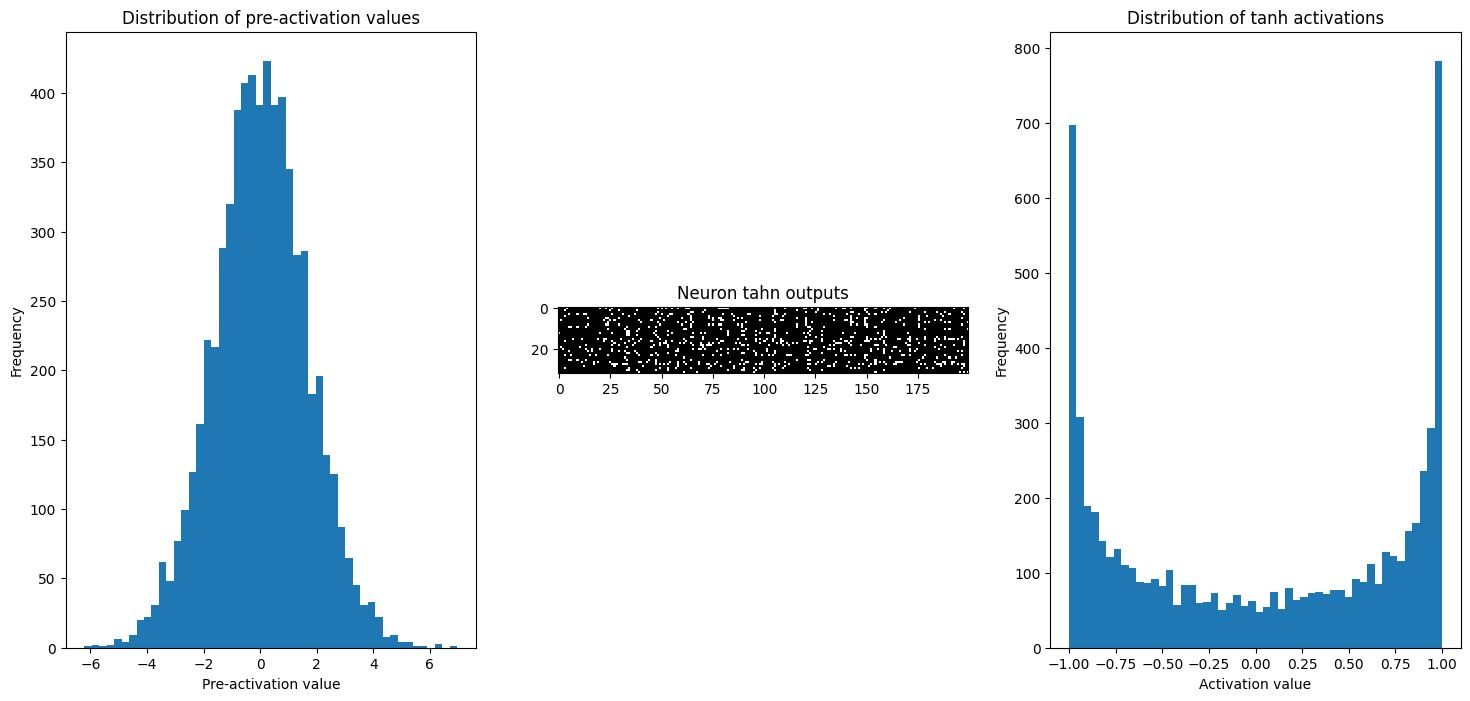

Epoch 0/1, Loss: 3.3302


In [2]:
model.train(training_epochs=1, plot_graphs=['tanh'])

Epoch 0/100000, Loss: 3.2042
Epoch 10000/100000, Loss: 1.2676
Epoch 20000/100000, Loss: 1.7162
Epoch 30000/100000, Loss: 1.4903
Epoch 40000/100000, Loss: 1.2612
Epoch 50000/100000, Loss: 1.2729
Epoch 60000/100000, Loss: 1.8278
Epoch 70000/100000, Loss: 1.8895
Epoch 80000/100000, Loss: 1.1886
Epoch 90000/100000, Loss: 1.3705


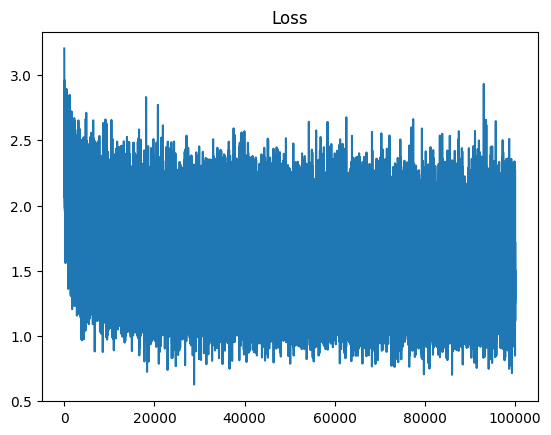

In [4]:
model.set_debug(False)
model.learning_rate = 0.1
model.train(training_epochs=100000, plot_graphs=['loss'])
# print("Loss on mini batches: ", model.current_loss)


In [7]:
print("Final loss on full dataset:", model.full_data_set_loss())

Final loss on full dataset: 1.4896420240402222


In [8]:
# print("train set sizes ", model.X_train.shape, model.Y_train.shape)
# print("dev set sizes ", model.X_dev.shape, model.Y_dev.shape)
# print("test set sizes ", model.X_test.shape, model.Y_test.shape)
print("dev set loss:", model.loss_on_dev_set())

dev set loss: 1.5808026790618896


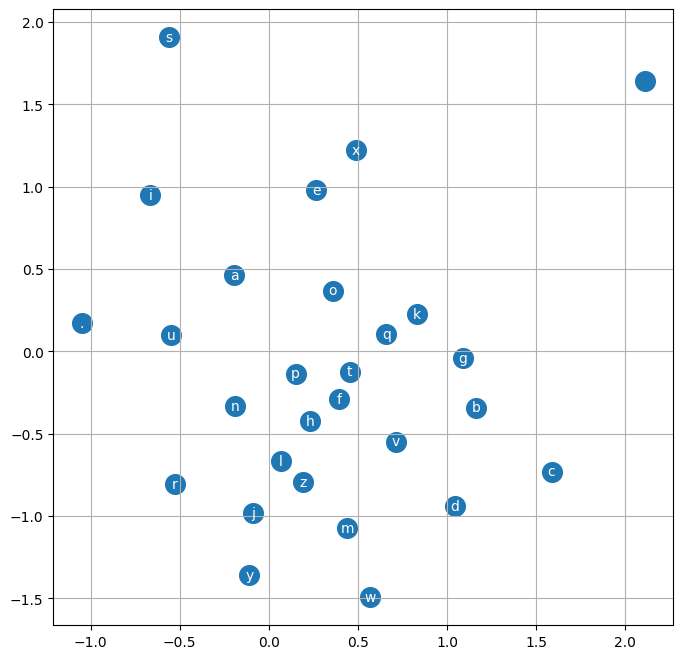

In [18]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,8))
plt.scatter(model.C[:,0].data, model.C[:,1].data, s=200)
for i in range(model.C.shape[0]):
    plt.text(model.C[i,0].item(), model.C[i,1].item(), model.i2c[i], ha="center", va="center", color='white')
plt.grid('minor')

In [5]:
model.loss_on_test_set()

1.5976276397705078

In [7]:
sample_words = model.sample_words(20)
print(sample_words)

['jahid', 'hander dam', 'kapil kumar', 'rajendeep kumar', 'mukesh  sin', 'dhra singh', 'pawat', 'anwat', 'anish kumar', 'ramar', 'meer kumar dayash', 'sumit kumar', 'nad', 'rajay', 'varu', 'buddineshveen', 'rajesh aashil pradheer kha', 'narat binder ala', 'ibrahul kumar khal', 'narafaesh vicky']


In [2]:


import torch
import torch.nn.functional as F

for _ in range(20):
    
    out = []
    context = [0] * model.block_size # initialize with all ...
    while True:
      emb = model.C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ model.W1 + model.b1)
      logits = h @ model.W2 + model.b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(model.i2c[i] for i in out))

edn.
eda.
ednnbhhva.
edncb.
ednnbhhva.
eda.
eda.
ednnb.
eda.
eda.
edncb.
ednntfhvygxfbmlmnok.
ednnbhhva.
eda.
eda.
eda.
eda.
ejtmlkrgmwv.
eda.
edncb.


Input mean: tensor(0.0116)
Input std: tensor(1.0140)
weight mean tensor(0.0004)
weight std tensor(0.9642)
Output mean: tensor(0.0058)
Output std: tensor(2.3864)


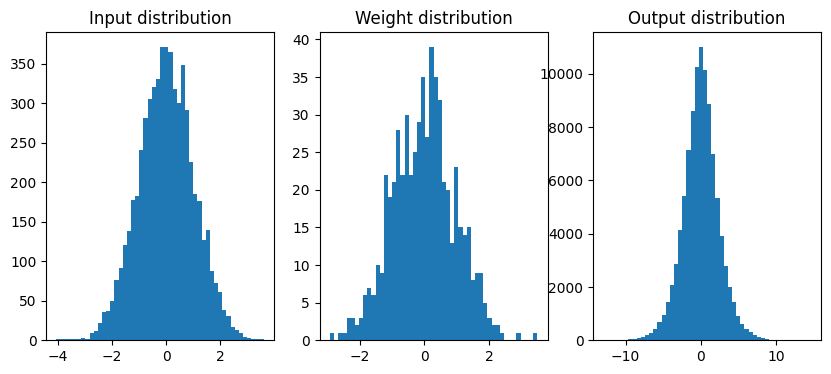

In [17]:
import matplotlib.pyplot as plt 
import torch
i = torch.randn((1000, 6)) 
print("Input mean:", i.mean())
print("Input std:", i.std())
w = torch.randn((6, 100))
print("weight mean", w.mean())
print("weight std", w.std())

y = i@w

print("Output mean:", y.mean())
print("Output std:", y.std())

plt.subplots(1,3, figsize=(10,4))
plt.subplot(1,3,1)
plt.hist(i.view(-1).tolist(), bins=50)
plt.title("Input distribution")

plt.subplot(1,3,2)
plt.hist(w.view(-1).tolist(), bins=50)
plt.title("Weight distribution")

plt.subplot(1,3,3)
plt.hist(y.view(-1).tolist(), bins=50)
plt.title("Output distribution")
plt.show()

